## **UA Innovate 2026: Using Machine Learning to Predict Device Behavior**

In [1]:
# --- Default libraries ---
import os
import pickle
import warnings
from pathlib import Path

# --- Working directory ---
PROJECT_DIR = Path().resolve()
PROJECT_ROOT_NAME = 'ua-innovate-2026'

while PROJECT_DIR.name != PROJECT_ROOT_NAME and PROJECT_DIR != PROJECT_DIR.parent:
    PROJECT_DIR = PROJECT_DIR.parent

if Path().resolve() != PROJECT_DIR:
    os.chdir(PROJECT_DIR)

DATA_DIR = PROJECT_DIR / 'data'
LOG_DIR = PROJECT_DIR / 'logs'

# --- Data preprocessing & visualization ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Machine learning ---
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, recall_score

# --- Custom modules ---
from src.utils import set_seed
from src.utils.data import clean_device_dataset
from src.utils.viz import plot_confusion_and_roc

# --- Settings ---
warnings.filterwarnings('ignore')
set_seed(42)

### **1. Data Preprocessing**

In [2]:
# Read in the device dataset
device_df = pd.read_csv(DATA_DIR / 'device_dataset.csv')

# Clean the device dataset
device_df = clean_device_dataset(device_df)

# Drop uninformative columns
device_df.drop(
    columns=[
        'device_name', 'device_source', 'location_matched', 'loc_site_name', 'loc_address_1',
        'loc_zip', 'loc_longitude', 'loc_latitude', 'device_reachability', 'device_vendor',
        'device_ip', 'serial_number', 'uptime', 'modeldata_in_scope', 'modeldata_dna_y_n',
        'modeldata_dna_part_number', 'modeldata_material_cost', 'modeldata_de_hrs', 'modeldata_se_hrs',
        'modeldata_fot_hrs', 'modeldata_de_cost', 'modeldata_se_cost', 'modeldata_fot_cost',
        'modeldata_labor_cost', 'modeldata_device_cost', 'modeldata_dna_cost', 'modeldata_staging_cost',
        'modeldata_tax_oh', 'repl_device_key', 'replacement_device_sku', 'replacement_device_cost',
        'replacement_labor_de_hours', 'replacement_labor_se_hours', 'replacement_labor_fo_hours',
        'pricing_component_count', 'pricing_total_estimate', 'source_device_id'
    ],
    inplace=True
)

# Filter the dataset with known location
device_df = device_df[device_df['loc_state'].notnull()].copy()

device_df.shape

(18845, 23)

In [3]:
# Inspect the dataframe
device_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18845 entries, 0 to 19234
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   state_code                18845 non-null  object 
 1   site_code                 18845 non-null  object 
 2   loc_state                 18845 non-null  object 
 3   loc_site_code             18845 non-null  object 
 4   loc_city                  18845 non-null  object 
 5   loc_county                17955 non-null  object 
 6   loc_call_group            18845 non-null  object 
 7   loc_owner                 18845 non-null  object 
 8   device_model              18836 non-null  object 
 9   device_type               18845 non-null  object 
 10  device_status             9060 non-null   object 
 11  software_version          18838 non-null  object 
 12  modeldata_model           18826 non-null  object 
 13  modeldata_model_parent    18755 non-null  object 
 14  modeldata_c

In [4]:
# Missingness preview (imputation will be fit on training data only via pipeline)
device_df.isna().mean().sort_values(ascending=False).head(10)

modeldata_repl_device     0.675033
modeldata_eos             0.660334
modeldata_eol             0.660334
free_ports                0.538870
total_ports               0.538870
ports_in_use              0.538870
device_status             0.519236
device_role               0.480923
loc_county                0.047227
modeldata_model_parent    0.004776
dtype: float64

In [5]:
# Separate data into known and unknown EoL datasets
known_eol_df = device_df[device_df['modeldata_eol'].notnull()].copy()
unknown_eol_df = device_df[device_df['modeldata_eol'].isnull()].copy()

# 3-class target based on days until EoL
known_eol_df['modeldata_eol'] = pd.to_datetime(known_eol_df['modeldata_eol'], errors='coerce')
today = pd.Timestamp.today().normalize()
known_eol_df['days_to_eol'] = (known_eol_df['modeldata_eol'] - today).dt.days
known_eol_df['target'] = np.select(
    [
        known_eol_df['days_to_eol'] < 0,
        known_eol_df['days_to_eol'] <= 365,
    ],
    [-1, 1],
    default=0,
).astype(int)

known_eol_df['target'].value_counts().sort_index()

target
-1    1173
 0    4470
 1     758
Name: count, dtype: int64

In [6]:
# Drop direct date leakage columns
known_eol_df.drop(columns=['days_to_eol', 'modeldata_eol'], inplace=True)
known_eol_df.shape

(6401, 23)

### **2. Train the Model**

In [7]:
# Features / target
features = known_eol_df.drop(columns=['target'])
target = known_eol_df['target']
groups = known_eol_df['device_model'].astype('string').fillna('UNKNOWN_MODEL')
class_labels = [-1, 0, 1]

def _pick_best_group_stratified_split(X, y, g, n_splits, random_state, target_ratio, target_frac):
    splitter = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    y_series = y.reset_index(drop=True)
    best = None
    for train_idx, test_idx in splitter.split(X, y, groups=g):
        fold = y_series.iloc[test_idx]
        fold_ratio = fold.value_counts(normalize=True)
        missing_classes = sum(1 for c in class_labels if c not in fold.unique())
        ratio_distance = sum(abs(fold_ratio.get(c, 0.0) - target_ratio.get(c, 0.0)) for c in class_labels)
        size_distance = abs((len(test_idx) / len(y_series)) - target_frac)
        score = (missing_classes * 10.0) + ratio_distance + size_distance
        if best is None or score < best[0]:
            best = (score, train_idx, test_idx)

    return best[1], best[2]

overall_ratio = target.value_counts(normalize=True)
train_val_idx, test_idx = _pick_best_group_stratified_split(
    features, target, groups, n_splits=5, random_state=42, target_ratio=overall_ratio, target_frac=0.20
)

X_train_val = features.iloc[train_val_idx].copy()
y_train_val = target.iloc[train_val_idx].copy()
groups_train_val = groups.iloc[train_val_idx].copy()

train_val_ratio = y_train_val.value_counts(normalize=True)
train_rel_idx, val_rel_idx = _pick_best_group_stratified_split(
    X_train_val, y_train_val, groups_train_val, n_splits=4, random_state=43, target_ratio=train_val_ratio, target_frac=0.25
)

X_train = X_train_val.iloc[train_rel_idx].copy()
y_train = y_train_val.iloc[train_rel_idx].copy()
X_val = X_train_val.iloc[val_rel_idx].copy()
y_val = y_train_val.iloc[val_rel_idx].copy()
X_test = features.iloc[test_idx].copy()
y_test = target.iloc[test_idx].copy()

# Train-only column filtering based on missingness
cols_to_drop = [col for col in X_train.columns if X_train[col].isna().mean() > 0.5]
X_train = X_train.drop(columns=cols_to_drop)
X_val = X_val.drop(columns=cols_to_drop)
X_test = X_test.drop(columns=cols_to_drop)

def _class_dist(y):
    counts = y.value_counts().reindex(class_labels, fill_value=0)
    pct = (counts / counts.sum()).round(3)

    return pd.DataFrame({'count': counts, 'pct': pct})

print("Train/Val/Test shapes:", X_train.shape, X_val.shape, X_test.shape)
print("Dropped columns (>50% missing in train):", cols_to_drop)
print("Unique models -> train/val/test:", X_train['device_model'].nunique(), X_val['device_model'].nunique(), X_test['device_model'].nunique())
print("\nClass distribution - train")
print(_class_dist(y_train))
print("\nClass distribution - val")
print(_class_dist(y_val))
print("\nClass distribution - test")
print(_class_dist(y_test))


Train/Val/Test shapes: (4484, 21) (1014, 21) (903, 21)
Dropped columns (>50% missing in train): ['device_role']
Unique models -> train/val/test: 36 10 17

Class distribution - train
        count    pct
target              
-1        867  0.193
 0       2887  0.644
 1        730  0.163

Class distribution - val
        count    pct
target              
-1        121  0.119
 0        888  0.876
 1          5  0.005

Class distribution - test
        count    pct
target              
-1        185  0.205
 0        695  0.770
 1         23  0.025


In [8]:
# Preprocessing pipeline fit on training split only
categorical_features = X_train.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
numeric_features = [col for col in X_train.columns if col not in categorical_features]

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
])

preprocessor = ColumnTransformer(
    transformers=[
        ('categorical', categorical_pipeline, categorical_features),
        ('numeric', numeric_pipeline, numeric_features),
    ],
    remainder='drop',
)

In [9]:
# Train model with preprocessing pipeline
random_forest = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=500,
        random_state=42,
        class_weight='balanced_subsample',
        min_samples_leaf=2
    )),
])

random_forest.fit(X_train, y_train)

# Baseline metrics
y_val_pred = random_forest.predict(X_val)
val_macro_f1 = f1_score(y_val, y_val_pred, average='macro')
val_per_class_recall = recall_score(y_val, y_val_pred, labels=[-1, 0, 1], average=None, zero_division=0)

print(f"Baseline Validation Macro-F1: {val_macro_f1:.4f}")
print(f"Baseline Validation Recall by class [-1, 0, 1]: {val_per_class_recall}")
print(classification_report(y_val, y_val_pred, labels=[-1, 0, 1], zero_division=0))

# Cost-sensitive decision rule tuning on validation set
classes = random_forest.named_steps['model'].classes_

def weighted_predict(model, X, class_weight_map):
    proba = model.predict_proba(X)
    weights = np.array([class_weight_map.get(int(c), 1.0) for c in classes], dtype=float)
    
    return classes[np.argmax(proba * weights, axis=1)]

best_val_macro_f1 = -1.0
best_class_weight_map = {-1: 1.0, 0: 1.0, 1: 1.0}
for w_neg in [1.0, 1.5, 2.0, 3.0, 4.0, 5.0]:
    for w_pos in [1.0, 1.5, 2.0, 3.0]:
        candidate_map = {-1: w_neg, 0: 1.0, 1: w_pos}
        y_val_pred_weighted = weighted_predict(random_forest, X_val, candidate_map)
        candidate_macro_f1 = f1_score(y_val, y_val_pred_weighted, average='macro')
        if candidate_macro_f1 > best_val_macro_f1:
            best_val_macro_f1 = candidate_macro_f1
            best_class_weight_map = candidate_map

print("Best decision weights from validation:", best_class_weight_map)
print(f"Best weighted Validation Macro-F1: {best_val_macro_f1:.4f}")

# Final validation and test metrics using weighted decision rule
y_val_pred_weighted = weighted_predict(random_forest, X_val, best_class_weight_map)
weighted_val_macro_f1 = f1_score(y_val, y_val_pred_weighted, average='macro')
weighted_val_recall = recall_score(y_val, y_val_pred_weighted, labels=[-1, 0, 1], average=None, zero_division=0)
print(f"Weighted Validation Macro-F1: {weighted_val_macro_f1:.4f}")
print(f"Weighted Validation Recall by class [-1, 0, 1]: {weighted_val_recall}")
print(classification_report(y_val, y_val_pred_weighted, labels=[-1, 0, 1], zero_division=0))

y_test_pred_weighted = weighted_predict(random_forest, X_test, best_class_weight_map)
test_macro_f1 = f1_score(y_test, y_test_pred_weighted, average='macro')
test_per_class_recall = recall_score(y_test, y_test_pred_weighted, labels=[-1, 0, 1], average=None, zero_division=0)

print(f"Weighted Test Macro-F1: {test_macro_f1:.4f}")
print(f"Weighted Test Recall by class [-1, 0, 1]: {test_per_class_recall}")
print(classification_report(y_test, y_test_pred_weighted, labels=[-1, 0, 1], zero_division=0))

Baseline Validation Macro-F1: 0.4001
Baseline Validation Recall by class [-1, 0, 1]: [0.14876033 1.         0.        ]
              precision    recall  f1-score   support

          -1       0.95      0.15      0.26       121
           0       0.89      1.00      0.94       888
           1       0.00      0.00      0.00         5

    accuracy                           0.89      1014
   macro avg       0.61      0.38      0.40      1014
weighted avg       0.89      0.89      0.86      1014

Best decision weights from validation: {-1: 1.5, 0: 1.0, 1: 1.0}
Best weighted Validation Macro-F1: 0.5437
Weighted Validation Macro-F1: 0.5437
Weighted Validation Recall by class [-1, 0, 1]: [0.76859504 0.93581081 0.        ]
              precision    recall  f1-score   support

          -1       0.61      0.77      0.68       121
           0       0.96      0.94      0.95       888
           1       0.00      0.00      0.00         5

    accuracy                           0.91      1014


In [10]:
# Visualize held-out test performance using weighted decision rule
class WeightedDecisionModel:
    def __init__(self, base_model, class_weight_map):
        self.base_model = base_model
        self.class_weight_map = class_weight_map
        self.classes_ = base_model.named_steps['model'].classes_

    def predict_proba(self, X):
        return self.base_model.predict_proba(X)

    def predict(self, X):
        proba = self.predict_proba(X)
        weights = np.array([self.class_weight_map.get(int(c), 1.0) for c in self.classes_], dtype=float)
        
        return self.classes_[np.argmax(proba * weights, axis=1)]

weighted_model = WeightedDecisionModel(random_forest, best_class_weight_map)
plot_confusion_and_roc(
    model=weighted_model,
    X_test=X_test,
    y_test=y_test,
    savefig='reports/model_performance.png'
)

In [11]:
# Save the model using pickle
with open('logs/random_forest_model.pkl', 'wb') as f:
    pickle.dump(random_forest, f)

### **3. Portfolio-Wide Behavior Scoring (Unknown EoL Inference)**
Run inference on `unknown_eol_df` only (devices with missing EoL date), which is the true production use case.
Predicted classes:
- `-1`: likely behaves like passed EoL
- `1`: likely approaches EoL within 12 months
- `0`: likely behaves like EoL > 365 days


In [12]:
# Predict behavior for unknown-EoL devices only
unknown_inference_df = unknown_eol_df.copy()

meta_cols = [
    'device_name', 'device_source', 'loc_state', 'loc_site_code', 'loc_site_name',
    'device_model', 'device_type', 'modeldata_eol'
]
meta_cols = [c for c in meta_cols if c in unknown_inference_df.columns]
meta_df = unknown_inference_df[meta_cols].copy()

# Start from the same baseline feature set used in model training
drop_cols_for_modeling = [
    'device_name', 'device_source', 'location_matched', 'loc_site_name', 'loc_address_1',
    'loc_zip', 'loc_longitude', 'loc_latitude', 'device_reachability', 'device_vendor',
    'device_ip', 'serial_number', 'uptime', 'modeldata_in_scope', 'modeldata_dna_y_n',
    'modeldata_dna_part_number', 'modeldata_material_cost', 'modeldata_de_hrs', 'modeldata_se_hrs',
    'modeldata_fot_hrs', 'modeldata_de_cost', 'modeldata_se_cost', 'modeldata_fot_cost',
    'modeldata_labor_cost', 'modeldata_device_cost', 'modeldata_dna_cost', 'modeldata_staging_cost',
    'modeldata_tax_oh', 'repl_device_key', 'replacement_device_sku', 'replacement_device_cost',
    'replacement_labor_de_hours', 'replacement_labor_se_hours', 'replacement_labor_fo_hours',
    'pricing_component_count', 'pricing_total_estimate', 'source_device_id'
]

feature_df = unknown_inference_df.drop(columns=[c for c in drop_cols_for_modeling if c in unknown_inference_df.columns]).copy()
feature_df = feature_df.drop(columns=['modeldata_eol'], errors='ignore')

# Apply train-only dropped columns discovered earlier
for col in cols_to_drop:
    if col in feature_df.columns:
        feature_df = feature_df.drop(columns=[col])

# Align inference frame to the training schema
for col in features.columns:
    if col not in feature_df.columns:
        feature_df[col] = np.nan
feature_df = feature_df[features.columns]

# Predict with weighted decision rule if available
if 'best_class_weight_map' in globals() and 'weighted_predict' in globals():
    y_pred_behavior = weighted_predict(random_forest, feature_df, best_class_weight_map)
    model_classes = random_forest.named_steps['model'].classes_
    base_proba = random_forest.predict_proba(feature_df)
    decision_weights = np.array([best_class_weight_map.get(int(c), 1.0) for c in model_classes], dtype=float)
    weighted_scores = base_proba * decision_weights
    pred_confidence = weighted_scores.max(axis=1)
else:
    y_pred_behavior = random_forest.predict(feature_df)
    pred_confidence = random_forest.predict_proba(feature_df).max(axis=1)

label_map = {
    -1: 'Likely Passed EoL',
    0: 'Likely EoL > 365d',
    1: 'Likely EoL <= 365d',
}

unknown_eol_predictions = meta_df.copy()
unknown_eol_predictions['predicted_behavior_class'] = y_pred_behavior.astype(int)
unknown_eol_predictions['predicted_behavior_label'] = unknown_eol_predictions['predicted_behavior_class'].map(label_map)
unknown_eol_predictions['prediction_confidence'] = pred_confidence

print('Unknown-EoL devices scored:', len(unknown_eol_predictions))
print(unknown_eol_predictions['predicted_behavior_class'].value_counts().sort_index())

unknown_eol_predictions.to_csv(DATA_DIR / 'unknown_eol_device_behavior_predictions.csv', index=False)
print('Saved:', DATA_DIR / 'unknown_eol_device_behavior_predictions.csv')

unknown_eol_predictions.sort_values('prediction_confidence', ascending=False).head(15)

Unknown-EoL devices scored: 12444
predicted_behavior_class
-1      121
 0    12323
Name: count, dtype: int64
Saved: C:\Users\Dell\Python\ua-innovate-2026\data\unknown_eol_device_behavior_predictions.csv


,loc_state,loc_site_code,device_model,device_type,modeldata_eol,predicted_behavior_class,predicted_behavior_label,prediction_confidence
8350,GA,XGD,NaN,Switch,NaN,0,Likely EoL > 365d,0.933519
8336,GA,XGD,NaN,Router,NaN,0,Likely EoL > 365d,0.932951
18459,IL,XNG,C9200-24P,Switch,NaN,0,Likely EoL > 365d,0.928752
18478,IL,XNG,C9200-48P,Switch,NaN,0,Likely EoL > 365d,0.925875
18474,IL,XNG,C9200-48P,Switch,NaN,0,Likely EoL > 365d,0.925875
18480,IL,XNG,C9200-48P,Switch,NaN,0,Likely EoL > 365d,0.925875
18476,IL,XNG,C9200-48P,Switch,NaN,0,Likely EoL > 365d,0.925875
18464,IL,XNG,C9200-48P,Switch,NaN,0,Likely EoL > 365d,0.925875
18477,IL,XNG,C9200-48P,Switch,NaN,0,Likely EoL > 365d,0.925875
18479,IL,XNG,C9200-48P,Switch,NaN,0,Likely EoL > 365d,0.925875


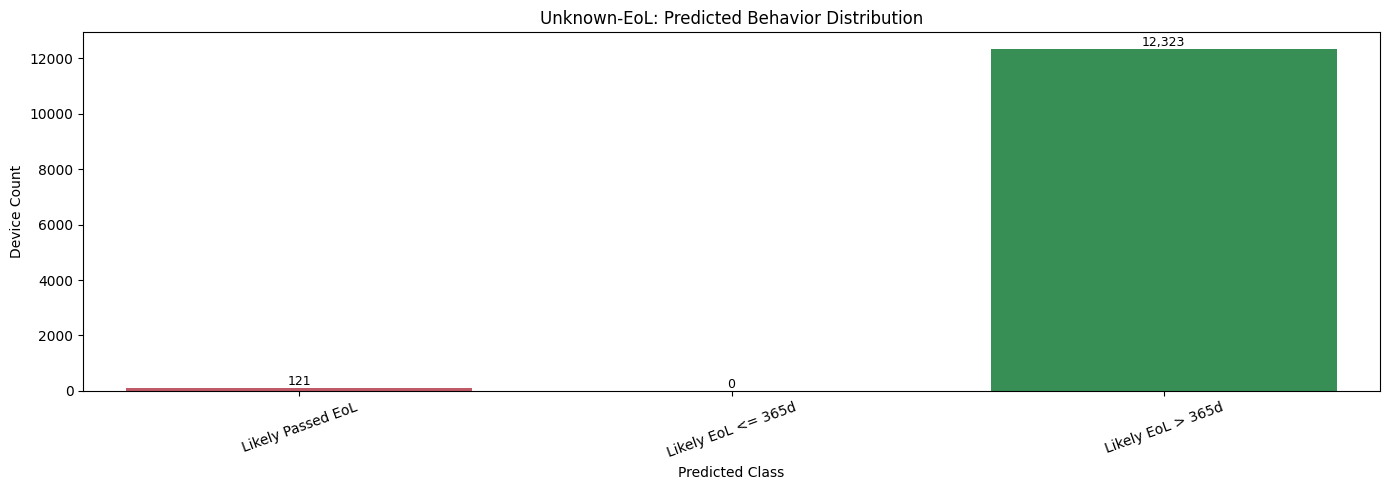

In [13]:
# Visualization: unknown-EoL predicted class mix + top states by predicted risk
plot_df = unknown_eol_predictions.copy()
plot_df['is_predicted_risk'] = plot_df['predicted_behavior_class'].isin([-1, 1])

summary_counts = (
    plot_df['predicted_behavior_label']
    .value_counts()
    .reindex(['Likely Passed EoL', 'Likely EoL <= 365d', 'Likely EoL > 365d'], fill_value=0)
)

state_risk = (
    plot_df[plot_df['loc_state'].notna()]
    .groupby('loc_state', as_index=False)
    .agg(
        total_devices=('predicted_behavior_class', 'size'),
        predicted_risk_devices=('is_predicted_risk', 'sum'),
    )
    .sort_values(['predicted_risk_devices', 'total_devices'], ascending=[False, False])
    .head(12)
)

fig = plt.figure(figsize=(14, 5))

sns.barplot(
    x=summary_counts.index,
    y=summary_counts.values,
    palette=['#d1495b', '#f2c14e', '#2a9d50'],
)
axes = plt.gca()
axes.set_title('Unknown-EoL: Predicted Behavior Distribution')
axes.set_xlabel('Predicted Class')
axes.set_ylabel('Device Count')
axes.tick_params(axis='x', rotation=20)
for i, v in enumerate(summary_counts.values):
    axes.text(i, v, f'{int(v):,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()